<a href="https://colab.research.google.com/github/RitalAlmutairi/Rital-ml-project/blob/main/01_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**00   Importing libraries**

In [ ]:
# First, we import Pandas ,NumPy and matplotlib, which are the core libraries for data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**01 load the dataset**

In [ ]:
# Loading the dataset for cleaning
insurance = pd.read_csv("/content/sample_data/insurance.csv") # Load the dataset from a CSV file
print("\nfirst 5 rows: \n",insurance.head())  # I printed the first five rows of the dataset


first 5 rows: 
    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


**02   Check the shape**

In [ ]:
print("\nthe shape:\n",insurance.shape) # Viewing dataset shape


the shape:
 (1338, 7)


**03   Inspect data types**

In [ ]:
print('\ninfo :\n',insurance.info()) #  Exploring dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

info :
 None


In [ ]:
print("\nDataset types:\n",insurance.dtypes)  # Checking the data types of each column
# I explored the types of dataxset and found that all types of data are suitable for its columns.


Dataset types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


**04    Find missing values**

In [ ]:
print("\nNumber of missing values for each column: \n",insurance.isnull().sum()) # Checking for missing values in each column
# I examined the dataset for missing values and found that all columns are complete with no null entries


Number of missing values for each column: 
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**05   Handle duplicates**

In [ ]:
insurance_cleaning = insurance.copy()
# Comparison of original and cleaned data
print("\nNumber of duplicated values for each column: \nbefore cleaning:",insurance.duplicated().sum())

insurance_cleaning.drop_duplicates(inplace=True) # At this Task, I used Google to search for the syntax of the pandas(inplace=True)function
print("\nafter cleaning:",insurance_cleaning.duplicated().sum())



Number of duplicated values for each column: 
before cleaning: 1

after cleaning: 0


**06   Spot outliers**

*   boxplot
*   IQR



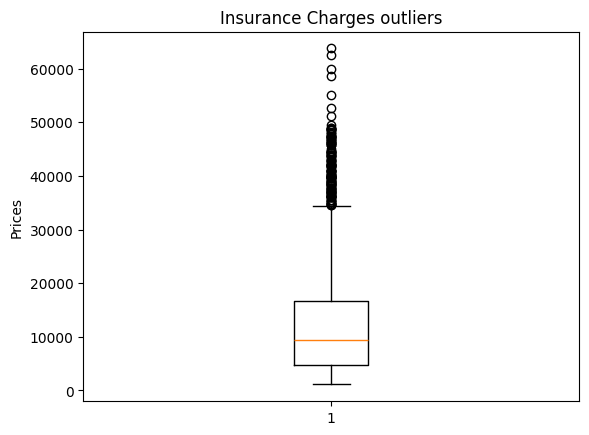

In [ ]:
# Visualizing outliers using a boxplot
plt.boxplot(insurance_cleaning['charges'])
plt.title('Insurance Charges outliers')
plt.ylabel('Prices')
plt.show()

In [ ]:
insurance_processed = insurance_cleaning.copy()
cap= insurance_processed['charges'].quantile(0.99)
insurance_processed["charges"] = insurance_processed["charges"].clip(upper=cap)
print("\nNew maximum value in charges:\n", insurance_processed['charges'].max())

Q1 = np.percentile(insurance_processed['charges'], 0.25)
Q3 = np.percentile(insurance_processed['charges'], 0.75)
IQR = Q3 - Q1
print("\nQ1:\n" ,Q1, "\nQ3:\n", Q3, "\nIQR:\n" ,IQR)


New maximum value in charges:
 48537.79687800001

Q1:
 1136.607344 
Q3:
 1241.5789 
IQR:
 104.97155599999996


**07   Write a clean_data()**

In [ ]:
def clean_data():
  insurance_processed = insurance.copy()
  print("\nNumber of duplicated values for each column: \nbefore cleaning:",insurance.duplicated().sum())
  insurance_processed.drop_duplicates(inplace=True)
  print("\nafter cleaning:",insurance_processed.duplicated().sum())
  cap= insurance_processed['charges'].quantile(0.99)
  insurance_processed["charges"] = insurance_processed["charges"].clip(upper=cap)
  print("\nNew maximum value in charges:\n", insurance_processed['charges'].max())
  Q1 = np.percentile(insurance_processed['charges'],0.25)
  Q3 = np.percentile(insurance_processed['charges'],0.75)
  IQR = Q3 - Q1
  print("\nQ1:\n" ,Q1, "\nQ3:\n", Q3, "\nIQR:\n" ,IQR)
  return insurance_processed


clean_data()



Number of duplicated values for each column: 
before cleaning: 1

after cleaning: 0

New maximum value in charges:
 48537.79687800001

Q1:
 1136.607344 
Q3:
 1241.5789 
IQR:
 104.97155599999996


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**08   Final three tasks checks**

In [ ]:
# 00 Check if there are any missing values left in the dataset
print("\nMissing values check:\n", insurance_processed.isnull().sum().sum())

# 01 Ensure all insurance charges are positive and realistic
print("\nMinimum charge check:\n", insurance_processed['charges'].min() > 0)

# 02 Confirm that we still have the correct number of columns
print("\nColumn count check:\n", insurance_processed.shape[1] == 7)


Missing values check:
 0

Minimum charge check:
 True

Column count check:
 True


In [ ]:
insurance_processed.to_csv("/content/insurance_processed.csv")
print(insurance_processed)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 columns]
